<div style="text-align: justify; padding:5px; background-color:rgb(252, 253, 255); border: 1px solid lightgrey; padding-left: 1em; padding-right: 1em;">
    
<h1> RF and PCLR (PCA + Logistic Regression) Workflow </h1>
<br>
<p style="text-align: justify">This Jupyter Notebook implements the complete workflow for creating, optimising, and evaluating a random forest (RF) model and PCLR (PCA + Logistic Regression). <b style="text-align: justify"></a> from scikit-learn.</b></p>

In [1]:


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


In [2]:
# 1. Load Data
file = 'MTBLS136.xlsx'

DataTable = pd.read_excel(file, sheet_name='Data')
PeakTable = pd.read_excel(file, sheet_name='Peak')

print("Data shape:", DataTable.shape)
print("Peak shape:", PeakTable.shape)


Data shape: (1649, 953)
Peak shape: (949, 4)


In [3]:
# 2. Binary Filtering (E vs E+P)
DataTable = DataTable[DataTable['Class'].isin([0.0, 1.0])]

Y = DataTable['Class'].replace({0.0:0, 1.0:1})
print(Y.value_counts())


Class
1.0    337
0.0    331
Name: count, dtype: int64


In [4]:
# 3. Feature Extraction & Cleaning
PeakList = PeakTable['Name']
PeakList = [p for p in PeakList if p in DataTable.columns]

X = DataTable[PeakList]

# Clean problematic columns
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, thresh=int(0.5 * len(X)))

# Align
mask = Y.notna()
X = X[mask]
Y = Y[mask]

print("Clean X shape:", X.shape)


Clean X shape: (668, 787)


In [5]:
# 4. Preprocessing
X_log = np.log1p(X)
X_log = pd.DataFrame(X_log).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

imputer = KNNImputer(n_neighbors=3)
X_imputed = imputer.fit_transform(X_scaled)

X_final = pd.DataFrame(X_imputed, columns=X.columns)
print("Processed shape:", X_final.shape)


Processed shape: (668, 787)


In [6]:
# 5. Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_final, Y, test_size=0.33, random_state=42, stratify=Y
)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# Train model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, Y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
train_acc = accuracy_score(Y_train, y_train_pred)
test_acc = accuracy_score(Y_test, y_test_pred)

fpr, tpr, _ = roc_curve(Y_test, y_prob)
rf_auc = auc(fpr, tpr)

print("RF Train Accuracy:", train_acc)
print("RF Test Accuracy:", test_acc)
print("RF AUC:", rf_auc)

RF Train Accuracy: 1.0
RF Test Accuracy: 0.6742081447963801
RF AUC: 0.7087223587223588


In [13]:
# ===============================
# 7. HYPERPARAMETER TUNING
# ===============================
param_grid = {
    'max_depth': [3,5,7],
    'min_samples_leaf': [0.05, 0.1],
    'max_features': ['sqrt'],
    'n_estimators': [100]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,
    verbose=1
)

grid.fit(X_train, Y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=1,
             param_grid={'max_depth': [3, 5, 7], 'max_features': ['sqrt'],
                         'min_samples_leaf': [0.05, 0.1],
                         'n_estimators': [100]},
             scoring='roc_auc', verbose=1)

In [14]:
# Train tuned model
best_rf = grid.best_estimator_

y_test_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:,1]

print("Tuned RF Accuracy:", accuracy_score(Y_test, y_test_pred_tuned))

fpr, tpr, _ = roc_curve(Y_test, y_prob_tuned)
rf_tuned_auc = auc(fpr, tpr)
print("Tuned RF AUC:", rf_tuned_auc)


Tuned RF Accuracy: 0.6606334841628959
Tuned RF AUC: 0.7113841113841115


In [15]:
# ===== Tuned RF Evaluation (FIX) =====

# Train predictions
y_train_pred_tuned = best_rf.predict(X_train)

# Test predictions (you already have this)
# y_test_pred_tuned = best_rf.predict(X_test)

# Accuracy
rf_tuned_train_acc = accuracy_score(Y_train, y_train_pred_tuned)
rf_tuned_test_acc = accuracy_score(Y_test, y_test_pred_tuned)

print("Tuned RF Train Accuracy:", rf_tuned_train_acc)
print("Tuned RF Test Accuracy:", rf_tuned_test_acc)

# AUC
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(Y_test, y_prob_rf_tuned)
rf_tuned_auc = auc(fpr, tpr)

print("Tuned RF AUC:", rf_tuned_auc)

Tuned RF Train Accuracy: 0.9194630872483222
Tuned RF Test Accuracy: 0.6606334841628959
Tuned RF AUC: 0.7113841113841115


Bootstrap AUC Mean: 0.6884922194922196
Bootstrap AUC Std: 0.019426511231691576


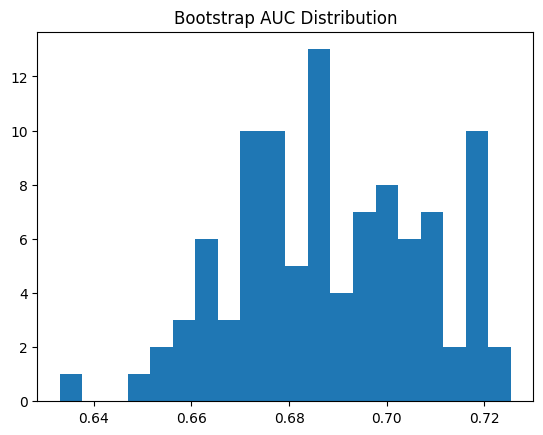

In [16]:
# ===============================
# 8. BOOTSTRAP EVALUATION
# ===============================
boot_auc = []

for i in range(100):
    X_res, Y_res = resample(X_train, Y_train)
    
    model = RandomForestClassifier(**grid.best_params_, random_state=42)
    model.fit(X_res, Y_res)
    
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    boot_auc.append(auc(fpr, tpr))

print("Bootstrap AUC Mean:", np.mean(boot_auc))
print("Bootstrap AUC Std:", np.std(boot_auc))

plt.hist(boot_auc, bins=20)
plt.title("Bootstrap AUC Distribution")
plt.show()


In [17]:
# ===============================
# 3. FEATURE EXTRACTION / SELECTION
# ===============================
from sklearn.feature_selection import VarianceThreshold, SelectFromModel

# Extract metabolite feature names from Peak table
PeakList = PeakTable['Name'].dropna().tolist()

# Keep only features موجود in dataset
PeakList = [p for p in PeakList if p in DataTable.columns]

# Create feature matrix
X = DataTable[PeakList].copy()

# Clean invalid values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove columns with >50% missing values
missing_threshold = int(0.5 * len(X))
X = X.dropna(axis=1, thresh=missing_threshold)

# Fill remaining missing values temporarily
X = X.fillna(X.median())

# Align target
mask = Y.notna()
X = X.loc[mask]
Y = Y.loc[mask]

print("Initial feature shape:", X.shape)

# -------------------------------
# Remove near-zero variance features
# -------------------------------
var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)

selected_columns = X.columns[var_selector.get_support()]
X_var = pd.DataFrame(X_var, columns=selected_columns)

print("After variance filtering:", X_var.shape)

# -------------------------------
# Feature importance extraction using Random Forest
# -------------------------------
rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_selector.fit(X_var, Y)

importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_var.columns
).sort_values(ascending=False)

# Select top 30 most important features
top_n = 30
top_features = importances.head(top_n).index.tolist()

X_selected = X_var[top_features]

print("Final selected feature shape:", X_selected.shape)
print("\nTop Selected Features:")
print(top_features)

Initial feature shape: (668, 787)
After variance filtering: (668, 787)
Final selected feature shape: (668, 30)

Top Selected Features:
['M41', 'M207', 'M618', 'M752', 'M39', 'M305', 'M84', 'M904', 'M667', 'M578', 'M57', 'M476', 'M407', 'M85', 'M537', 'M806', 'M123', 'M38', 'M304', 'M28', 'M29', 'M301', 'M162', 'M212', 'M803', 'M868', 'M506', 'M307', 'M886', 'M891']


# ===============================
 PCLR (PCA + Logistic Regression)
# ===============================

In [18]:
# ===============================

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pclr = LogisticRegression(max_iter=1000)
pclr.fit(X_train_pca, Y_train)

y_pred_pclr = pclr.predict(X_test_pca)
y_prob_pclr = pclr.predict_proba(X_test_pca)[:,1]

pclr_acc = accuracy_score(Y_test, y_pred_pclr)

fpr, tpr, _ = roc_curve(Y_test, y_prob_pclr)
pclr_auc = auc(fpr, tpr)

print("PCLR Accuracy:", pclr_acc)
print("PCLR AUC:", pclr_auc)


PCLR Accuracy: 0.6470588235294118
PCLR AUC: 0.7153153153153152


In [19]:
# ===============================
#  PCLR TUNED (Logistic Regression tuning)
# ===============================
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,
    verbose=1
)

grid_lr.fit(X_train_pca, Y_train)

best_pclr = grid_lr.best_estimator_

y_pred_pclr_tuned = best_pclr.predict(X_test_pca)
y_prob_pclr_tuned = best_pclr.predict_proba(X_test_pca)[:,1]

pclr_tuned_acc = accuracy_score(Y_test, y_pred_pclr_tuned)

fpr, tpr, _ = roc_curve(Y_test, y_prob_pclr_tuned)
pclr_tuned_auc = auc(fpr, tpr)

print("Tuned PCLR Accuracy:", pclr_tuned_acc)
print("Tuned PCLR AUC:", pclr_tuned_auc)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Tuned PCLR Accuracy: 0.6742081447963801
Tuned PCLR AUC: 0.7382473382473382


In [20]:
# ===== Tuned PCLR Evaluation =====

# Train predictions
y_train_pred_pclr_tuned = best_pclr.predict(X_train_pca)

# Accuracy
pclr_tuned_train_acc = accuracy_score(Y_train, y_train_pred_pclr_tuned)
pclr_tuned_test_acc = accuracy_score(Y_test, y_pred_pclr_tuned)

print("Tuned PCLR Train Accuracy:", pclr_tuned_train_acc)
print("Tuned PCLR Test Accuracy:", pclr_tuned_test_acc)

# AUC
y_prob_pclr_tuned = best_pclr.predict_proba(X_test_pca)[:, 1]

fpr, tpr, _ = roc_curve(Y_test, y_prob_pclr_tuned)
pclr_tuned_auc = auc(fpr, tpr)

print("Tuned PCLR AUC:", pclr_tuned_auc)

Tuned PCLR Train Accuracy: 0.9552572706935123
Tuned PCLR Test Accuracy: 0.6742081447963801
Tuned PCLR AUC: 0.7382473382473382


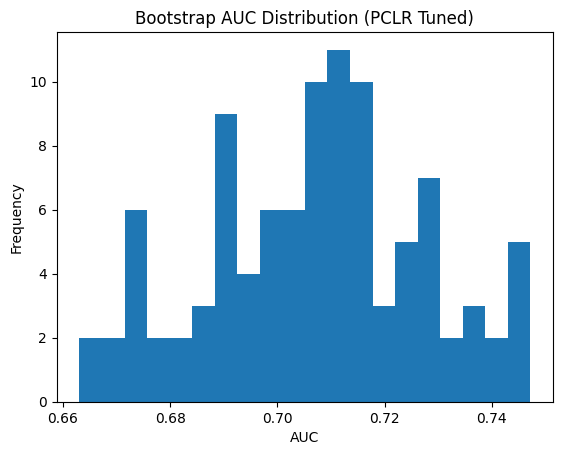

Mean AUC: 0.7071244881244881
Std AUC: 0.02026513057879871


<Figure size 640x480 with 0 Axes>

In [21]:
# ===============================
# Bootstrapping 
# ===============================
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

boot_auc = []

for i in range(100):
    X_res, Y_res = resample(X_train_pca, Y_train)

    model = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
    model.fit(X_res, Y_res)

    y_prob = model.predict_proba(X_test_pca)[:,1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    boot_auc.append(auc(fpr, tpr))

# Plot
plt.hist(boot_auc, bins=20)
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.title("Bootstrap AUC Distribution (PCLR Tuned)")
plt.show()

print("Mean AUC:", np.mean(boot_auc))
print("Std AUC:", np.std(boot_auc))
plt.savefig("bootstrap AUC Distribution.png", dpi=300, bbox_inches='tight')

In [22]:
# ===============================
#  FINAL COMPARISON
# ===============================
results = pd.DataFrame({
    'Model': ['RF', 'RF Tuned', 'PCLR', 'PCLR Tuned'],
    'Accuracy': [rf_test_acc, rf_tuned_auc, pclr_acc, pclr_tuned_acc],
    'AUC': [rf_auc, rf_tuned_auc, pclr_auc, pclr_tuned_auc]
})



In [23]:
results = pd.DataFrame({
    'Model': ['RF', 'RF Tuned', 'PCLR', 'PCLR Tuned'],
    'Train Accuracy': [
        rf_train_acc,
        rf_tuned_train_acc,
        accuracy_score(Y_train, pclr.predict(X_train_pca)),
        accuracy_score(Y_train, best_pclr.predict(X_train_pca))
    ],
    'Test Accuracy': [
        rf_test_acc,
        rf_tuned_test_acc,
        pclr_acc,
        pclr_tuned_acc
    ],
    'AUC': [
        rf_auc,
        rf_tuned_auc,
        pclr_auc,
        pclr_tuned_auc
    ]
})

print(results)

        Model  Train Accuracy  Test Accuracy       AUC
0          RF        1.000000       0.638009  0.708722
1    RF Tuned        0.919463       0.660633  0.711384
2        PCLR        1.000000       0.647059  0.715315
3  PCLR Tuned        0.955257       0.674208  0.738247


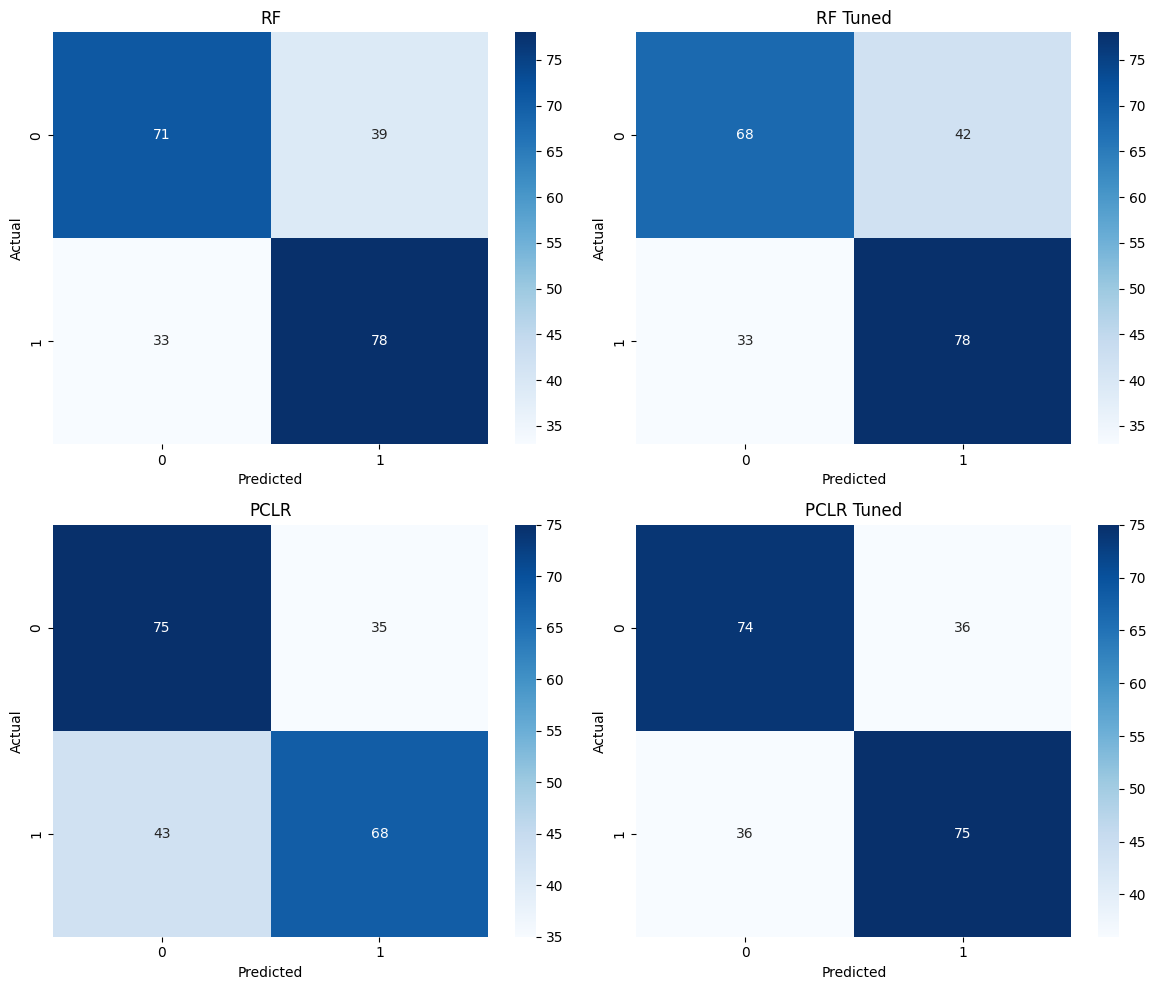

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "RF": y_test_pred,
    "RF Tuned": y_test_pred_tuned,
    "PCLR": y_pred_pclr,
    "PCLR Tuned": y_pred_pclr_tuned
}

plt.figure(figsize=(12,10))

for i, (name, preds) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    cm = confusion_matrix(Y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [28]:
# Save results
results.to_excel('Final_Model_Comparison.xlsx', index=False)
print("Saved successfully")


Saved successfully


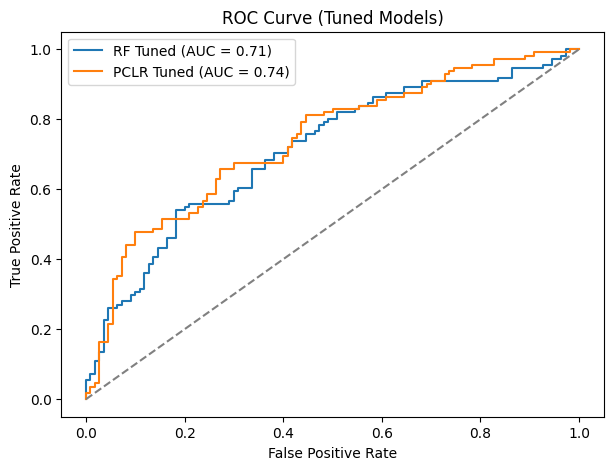

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# ===== RF Tuned =====
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_prob_rf_tuned)
rf_tuned_auc = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, label=f"RF Tuned (AUC = {rf_tuned_auc:.2f})")

# ===== PCLR Tuned =====
fpr_pclr, tpr_pclr, _ = roc_curve(Y_test, y_prob_pclr_tuned)
pclr_tuned_auc = auc(fpr_pclr, tpr_pclr)

plt.plot(fpr_pclr, tpr_pclr, label=f"PCLR Tuned (AUC = {pclr_tuned_auc:.2f})")

# ===== Baseline diagonal =====
plt.plot([0,1],[0,1],'--', color='gray')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tuned Models)")
plt.legend()
plt.savefig("roc_tuned_models.png", dpi=300, bbox_inches='tight')

plt.show()

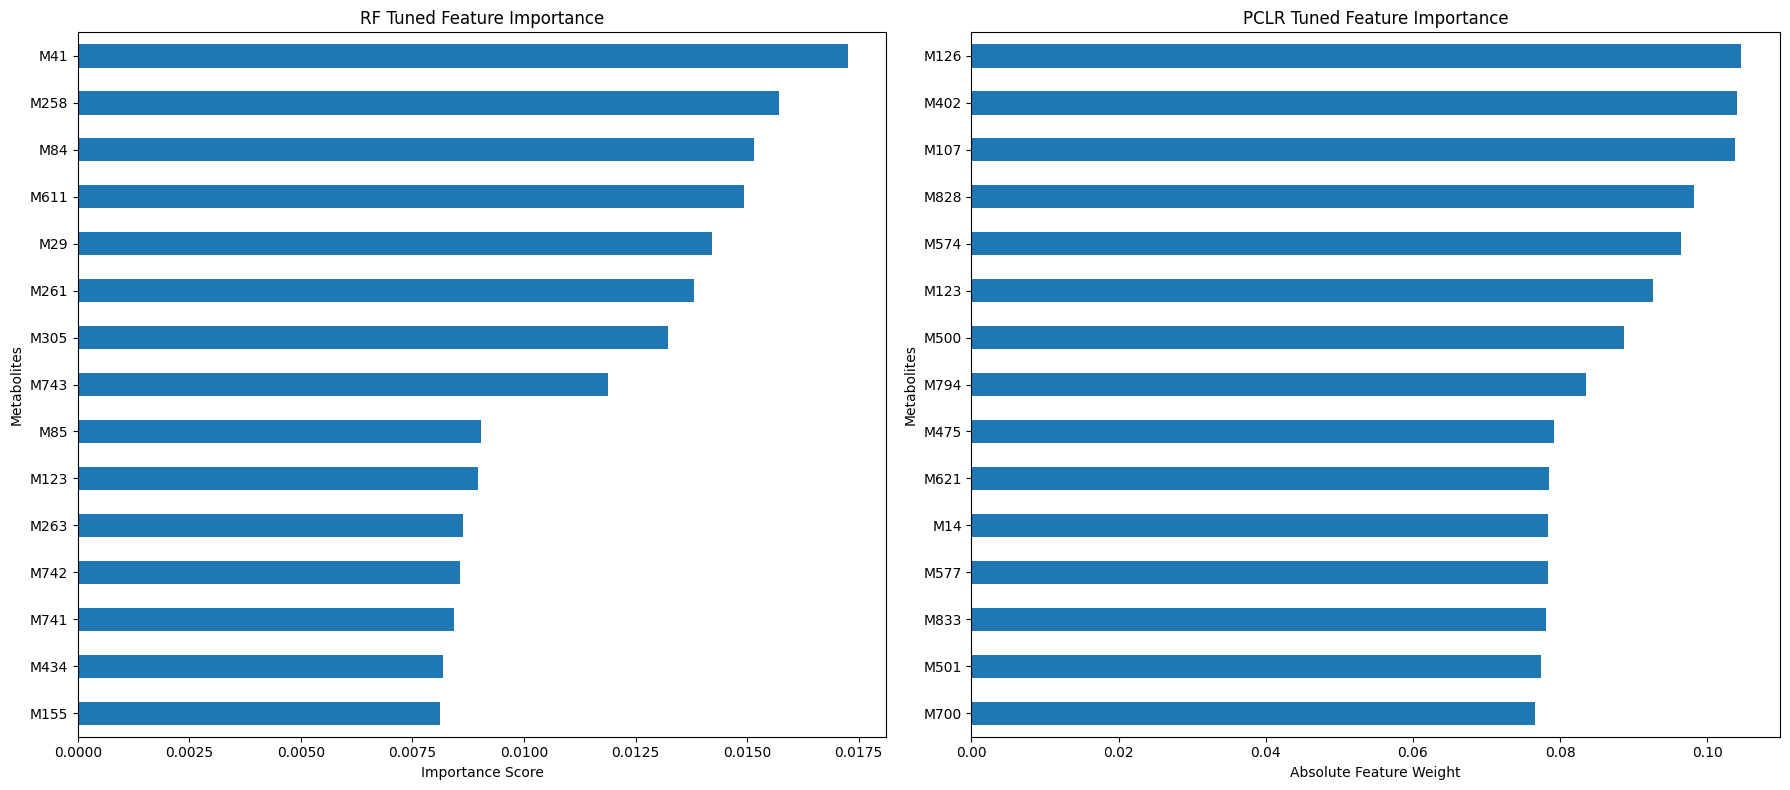

In [33]:
# ===============================
# SIDE-BY-SIDE FEATURE IMPORTANCE
# RF Tuned vs PCLR Tuned
# ===============================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# RF Tuned importance
# -------------------------------
rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_rf = rf_importance.head(15)

# -------------------------------
# PCLR Tuned importance
# -------------------------------
# Map PCA+LogReg coefficients back to original feature space
original_feature_weights = np.dot(
    pca.components_.T,
    best_pclr.coef_.flatten()
)

pclr_importance = pd.Series(
    np.abs(original_feature_weights),
    index=X_train.columns
).sort_values(ascending=False)

top_pclr = pclr_importance.head(15)

# -------------------------------
# Side-by-side plots
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# RF plot
top_rf.sort_values().plot(
    kind='barh',
    ax=axes[0]
)
axes[0].set_title('RF Tuned Feature Importance')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Metabolites')

# PCLR plot
top_pclr.sort_values().plot(
    kind='barh',
    ax=axes[1]
)
axes[1].set_title('PCLR Tuned Feature Importance')
axes[1].set_xlabel('Absolute Feature Weight')
axes[1].set_ylabel('Metabolites')

plt.tight_layout()
plt.show()